# 분석목표

디커플링 진입 12개월 전부터 특정 변수들이 평균적으로 유의하게 움직이는가?

1. 디커플링 진입 시점 추출

2. 이벤트 윈도우 생성 (t-12 ~ t-1)

3. 변수별 평균 궤적 계산

4. 정상구간과 비교

5. lag correlation 계산

6. 진입 확률 로지스틱 모형

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "data/preprocessed/"

#데이터 로드
dec = pd.read_csv("data/decoupling.csv")
fx  = pd.read_csv(BASE + "전처리_환율.csv")
sp  = pd.read_csv(BASE + "전처리_신용스프레드.csv")
m2  = pd.read_csv(BASE + "전처리_M2.csv")
ret = pd.read_csv(BASE + "전처리_소매판매액지수.csv")
ipi = pd.read_csv(BASE + "전처리_전산업생산지수.csv")

# 날짜 변환
for df in [dec, fx, sp, m2, ret, ipi]:
    df["date"] = pd.to_datetime(df["date"])

병합
panel = dec[["date","gap","top_regime"]].copy()

panel = panel.merge(fx[["date","exchange"]], on="date", how="left")
panel = panel.merge(sp[["date","credit_spread"]], on="date", how="left")
panel = panel.merge(m2[["date","M2"]], on="date", how="left")
panel = panel.merge(ret[["date","retail_z"]], on="date", how="left")
panel = panel.merge(ipi[["date","ipi"]], on="date", how="left")

panel = panel.sort_values("date").reset_index(drop=True)

print(panel.tail())

          date       gap  top_regime  exchange  credit_spread         M2  \
246 2025-07-01  0.193536       False   1392.47          0.492  3997486.9   
247 2025-08-01  0.708974       False   1388.97          0.487  4040694.6   
248 2025-09-01  0.194654       False   1404.14          0.462  4057516.7   
249 2025-10-01  1.479528        True   1429.22          0.427  4059450.7   
250 2025-11-01  0.978346        True   1467.62          0.419  4057549.3   

     retail_z    ipi  
246 -0.015756  114.6  
247 -0.810666  114.3  
248 -0.092358  115.8  
249 -0.594290  112.8  
250 -0.490559  113.8  


In [9]:
def extract_entry(mask):
    entries = []
    prev = False
    for i, m in enumerate(mask):
        if m and not prev:
            entries.append(i)
        prev = m
    return entries

entries = extract_entry(panel["top_regime"].values)
entry_dates = panel.loc[entries,"date"]

print("진입 시점:", entry_dates.tolist())

진입 시점: [Timestamp('2005-01-01 00:00:00'), Timestamp('2005-04-01 00:00:00'), Timestamp('2005-07-01 00:00:00'), Timestamp('2009-10-01 00:00:00'), Timestamp('2010-01-01 00:00:00'), Timestamp('2013-05-01 00:00:00'), Timestamp('2013-09-01 00:00:00'), Timestamp('2015-01-01 00:00:00'), Timestamp('2017-10-01 00:00:00'), Timestamp('2017-12-01 00:00:00'), Timestamp('2020-03-01 00:00:00'), Timestamp('2020-11-01 00:00:00'), Timestamp('2023-07-01 00:00:00'), Timestamp('2023-12-01 00:00:00'), Timestamp('2024-03-01 00:00:00'), Timestamp('2024-06-01 00:00:00'), Timestamp('2024-09-01 00:00:00'), Timestamp('2025-10-01 00:00:00')]


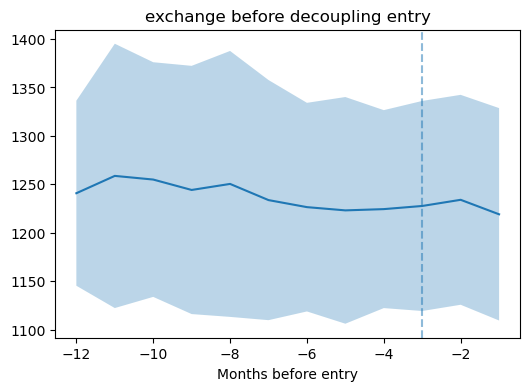

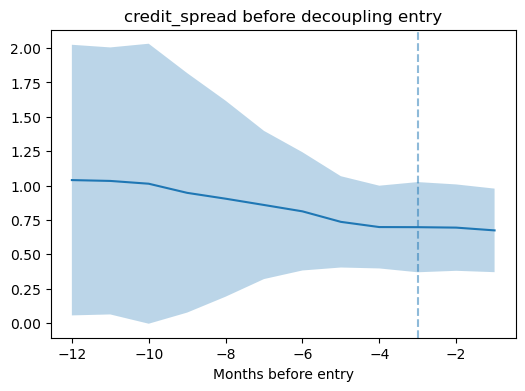

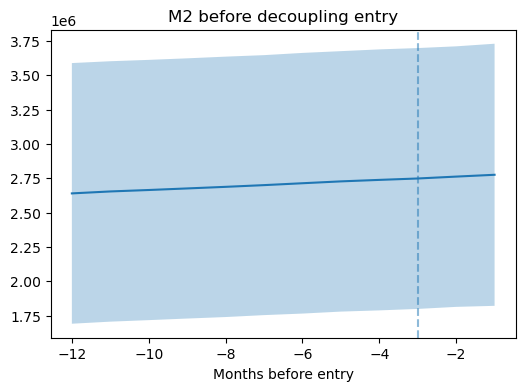

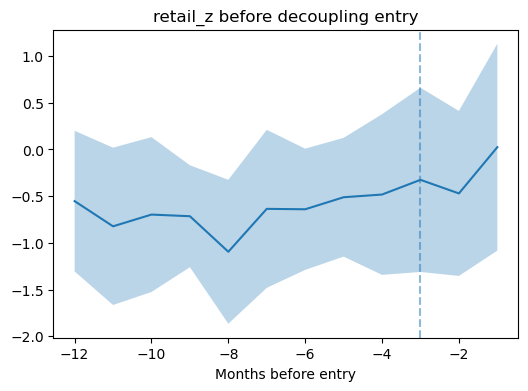

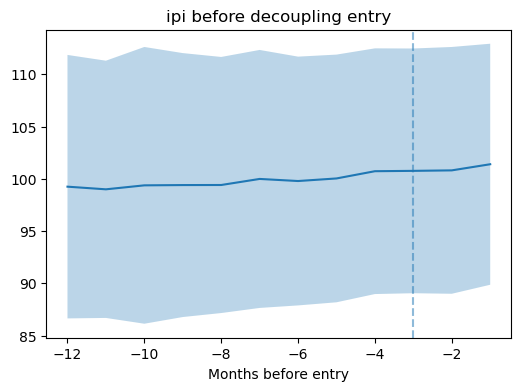

In [16]:
WINDOW = 12
variables = ["exchange","credit_spread","M2","retail_z","ipi"]

event_mat = {v: [] for v in variables}

for idx in entries:
    if idx - WINDOW < 0:
        continue
    w = panel.iloc[idx-WINDOW:idx]
    for v in variables:
        event_mat[v].append(w[v].values)

lags = np.arange(-WINDOW,0)
i=0
for v in variables:
    i+=1
    arr = np.array(event_mat[v])
    if len(arr)==0:
        continue
    
    mean = np.nanmean(arr,axis=0)
    std  = np.nanstd(arr,axis=0)
    
    plt.figure(figsize=(6,4))
    plt.plot(lags, mean)
    plt.fill_between(lags, mean-std, mean+std, alpha=0.3)
    plt.axvline(-3, linestyle="--", alpha=0.5)
    plt.title(f"{v} before decoupling entry")
    plt.xlabel("Months before entry")
    plt.savefig('result'+str(i)+'.png')
    plt.show()

In [18]:
max_lag = 12
lag_corr = {}

for v in variables:
    corr_list = []
    for k in range(1,max_lag+1):
        corr = panel[v].shift(k).corr(panel["gap"])
        corr_list.append(corr)
    lag_corr[v] = corr_list

lag_df = pd.DataFrame(lag_corr, index=range(1,max_lag+1))
print(lag_df)

    exchange  credit_spread        M2  retail_z       ipi
1  -0.010994      -0.294958  0.125792 -0.013481  0.106783
2   0.065125      -0.237472  0.137239 -0.066608  0.119109
3   0.118952      -0.178181  0.144820 -0.061377  0.128156
4   0.171613      -0.127359  0.156051 -0.108851  0.140631
5   0.214777      -0.076909  0.164438 -0.249961  0.142781
6   0.282623      -0.025764  0.170823 -0.239388  0.152799
7   0.326985       0.026963  0.182557 -0.261822  0.170679
8   0.379542       0.071532  0.187267 -0.395017  0.168727
9   0.411393       0.119340  0.194840 -0.422011  0.185107
10  0.436660       0.156680  0.199441 -0.407662  0.197938
11  0.473744       0.180495  0.200748 -0.358625  0.202116
12  0.501895       0.184767  0.199854 -0.200835  0.220692


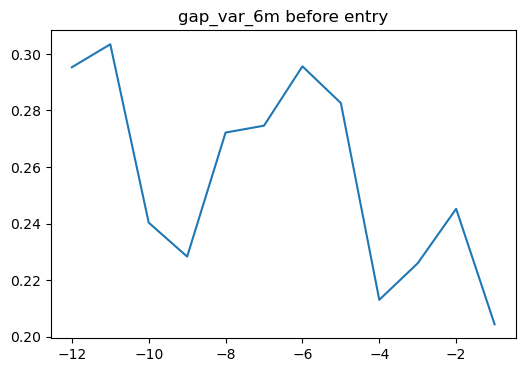

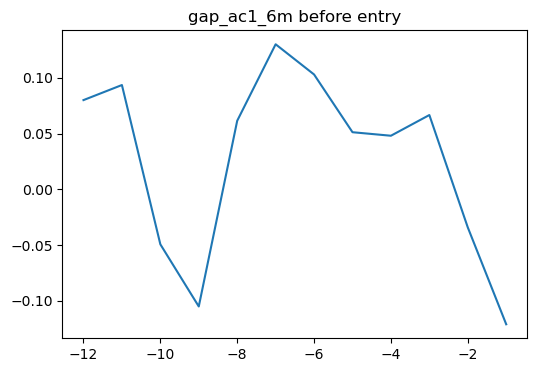

In [19]:
panel["gap_var_6m"] = panel["gap"].rolling(6).var()
panel["gap_ac1_6m"] = panel["gap"].rolling(6).apply(lambda x: x.autocorr())

extra_vars = ["gap_var_6m","gap_ac1_6m"]
i=0
for v in extra_vars:
    i+=1
    event_mat[v] = []
    for idx in entries:
        if idx - WINDOW < 0:
            continue
        w = panel.iloc[idx-WINDOW:idx]
        event_mat[v].append(w[v].values)
    
    arr = np.array(event_mat[v])
    mean = np.nanmean(arr,axis=0)
    
    plt.figure(figsize=(6,4))
    plt.plot(lags, mean)
    plt.title(f"{v} before entry")
    plt.savefig('result2_'+str(i)+'.png')
    plt.show()